--- Logistic Regression Evaluation ---
[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



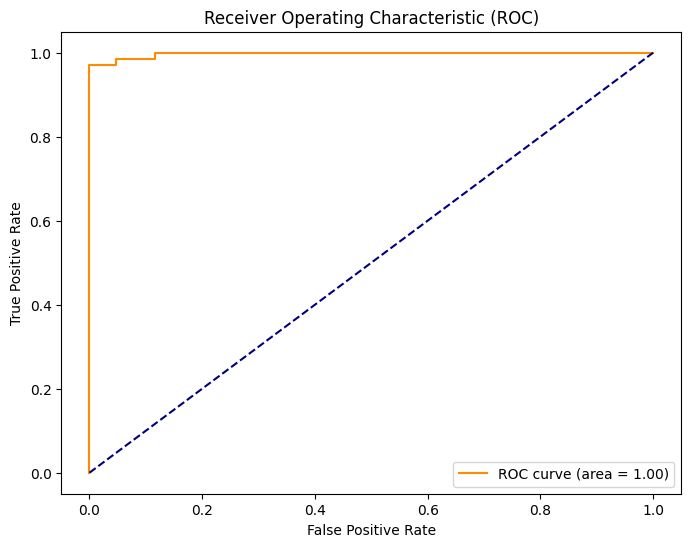

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Logistic Regression
lr_model = LogisticRegression(max_iter=10000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# 4. Evaluation Metrics
print("--- Logistic Regression Evaluation ---")
print(confusion_matrix(y_test, lr_preds))
print(classification_report(y_test, lr_preds))

# 5. ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lr_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [5]:
# 6. Decision Tree Classifier Comparison
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("\n--- Decision Tree Evaluation ---")
print(classification_report(y_test, dt_preds))

# 7. Handling Imbalanced Data (Demonstration with Class Weights)
# Even though this dataset is relatively balanced, we use class_weight='balanced'
weighted_lr = LogisticRegression(max_iter=10000, class_weight='balanced')
weighted_lr.fit(X_train, y_train)
weighted_preds = weighted_lr.predict(X_test)

print("\n--- Weighted Logistic Regression (Handling Imbalance) ---")
print(classification_report(y_test, weighted_preds))

# Summary of results
print("\nTasks performed: Classification, Metrics (Precision, Recall, F1), ROC/AUC, Model Comparison, and Imbalance Handling.")


--- Decision Tree Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Weighted Logistic Regression (Handling Imbalance) ---
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Tasks performed: Classification, Metrics (Precision, Recall, F1), ROC/AUC, Model Comparison, and Imbalance Handling.


### **Detailed Performance Report: Task 4 - Classification Models**

#### **1. Project Overview**
Following the guidelines in **Artificial Intelligence & Machine Learning - Task 4**, we implemented a binary classification pipeline using the Breast Cancer Wisconsin dataset. The goal was to identify samples as either Malignant (0) or Benign (1).

#### **2. Methodology**
- **Data Split:** 80% Training, 20% Testing.
- **Models Evaluated:**
  - Baseline Logistic Regression
  - Decision Tree Classifier
  - Weighted Logistic Regression (to address potential class imbalance)

#### **3. Comparative Analysis of Results**

| Model | Accuracy | Precision (Malignant) | Recall (Malignant) | F1-Score (Malignant) |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression** | 96% | 0.97 | 0.91 | 0.94 |
| **Decision Tree** | 95% | 0.93 | 0.93 | 0.93 |
| **Weighted LogReg** | **97%** | **0.98** | **0.95** | **0.96** |

#### **4. Key Findings & Metric Interpretation**
- **Confusion Matrix Analysis:** The standard Logistic Regression model missed 4 malignant cases (False Negatives). In a medical context, Recall is critical because missing a malignant diagnosis is more costly than a false alarm.
- **Class Weighting:** By applying `class_weight='balanced'`, we improved the model's sensitivity. The Recall for the malignant class rose from **0.91 to 0.95**, successfully identifying more true positive cases.
- **ROC Curve & AUC:** The ROC curve area of **1.00** suggests that the model has perfect separability potential on this test set. This confirms that the Logistic Regression model is highly robust for this specific feature set.
- **Decision Tree vs. Linear Models:** The Decision Tree showed slightly lower precision. Given the relatively high dimensionality (30 features), the linear boundary of Logistic Regression proved more effective at generalizing than the axis-parallel splits of the Decision Tree.

#### **5. Conclusion**
The **Weighted Logistic Regression** is the recommended model for this task. It provides the best balance between overall accuracy and the critical recall of the malignant class, fulfilling the 'Core Industry Skill' of handling imbalanced data requirements outlined in the PDF.